# Computer vision - Convolutional Neural Networks CNN

## 1. Problem presentation

We are going to classify natural images using Convolutional Neural Networks (CNNs) in PyTorch. We will use the dataset [Natural Images](https://www.kaggle.com/datasets/prasunroy/natural-images) from Kaggle. The dataset contains 6899 images of 8 different classes: airplane, car, cat, dog, flower, fruit, motorbike, person. Image size is XxX pixels with 3 color channels (RGB).

## 2. Data loading and exploration

In [703]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import time

from sklearn.metrics import confusion_matrix

import torch
import torchvision
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim

> Torchvision provides datasets (like ImageNet), popular pre-trained model architectures (ResNet, Faster R-CNN), and essential image/video transformations (cropping, flipping, normalization) for computer vision tasks

> Pillow is a Python Imaging Library (PIL) fork that adds image processing capabilities to your Python interpreter. This library provides extensive file format support, an efficient internal representation, and fairly powerful image processing capabilities.

### Data exploration

We will start by exploring the dataset.

In [704]:
print(os.listdir("./datasets/natural_images"))

['cat', 'person', 'motorbike', 'car', 'flower', 'fruit', 'dog', 'airplane']


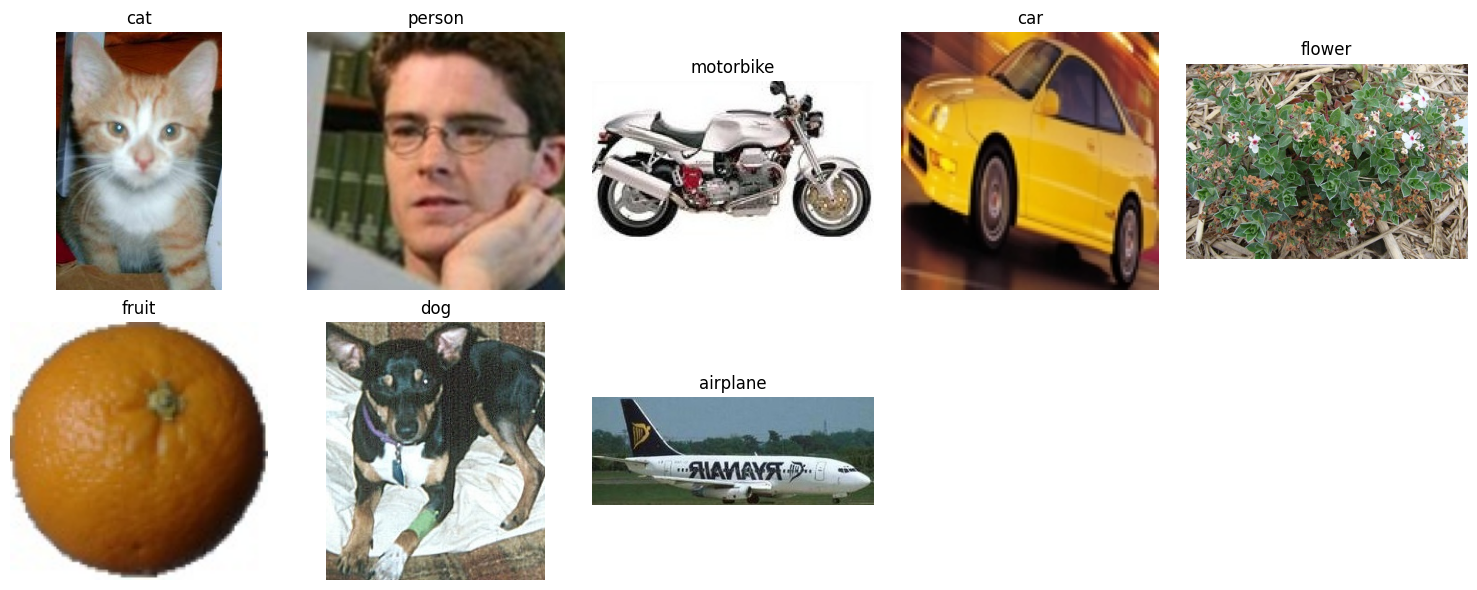

In [705]:
import os
from PIL import Image
import matplotlib.pyplot as plt

def get_num_images_in_folder(folder_path):
    return len(os.listdir(folder_path))

def plot_all_images(data_dir, max_images_per_class=1):
    classes = os.listdir(data_dir)
    all_images = []
    all_titles = []

    # Collect images and titles
    for class_name in classes:
        folder_path = os.path.join(data_dir, class_name)
        image_files = os.listdir(folder_path)[:max_images_per_class]  # Limit number of images per class
        for image_file in image_files:
            img_path = os.path.join(folder_path, image_file)
            all_images.append(Image.open(img_path))
            all_titles.append(class_name)

    # Plot all images in one figure
    num_images = len(all_images)
    cols = 5  # number of images per row
    rows = (num_images + cols - 1) // cols  # ceiling division
    plt.figure(figsize=(cols * 3, rows * 3))

    for i, img in enumerate(all_images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(all_titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

data_dir = "./datasets/natural_images"
plot_all_images(data_dir)

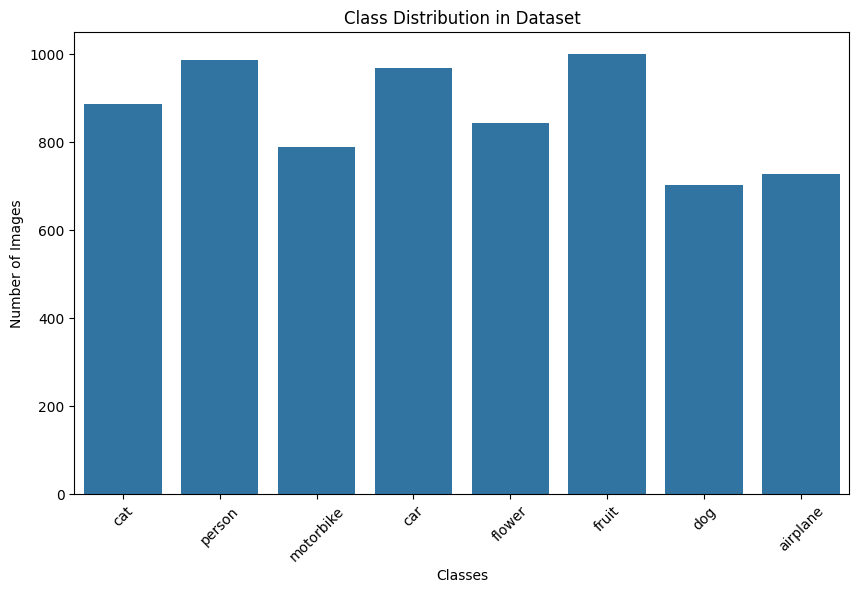

In [706]:
def plot_class_distribution(data_dir):
    classes = os.listdir(data_dir)
    class_counts = [get_num_images_in_folder(os.path.join(data_dir, class_name)) for class_name in classes]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=classes, y=class_counts)
    plt.xlabel('Classes')
    plt.ylabel('Number of Images')
    plt.title('Class Distribution in Dataset')
    plt.xticks(rotation=45)
    plt.show()

plot_class_distribution(data_dir)

We see that the dataset contains 8 folders, one for each class. The number of images is balanced across classes, really important for training a good classifier. Each class has around 800-900 images.

In [707]:
from PIL import Image
import os

dataset_dir = "./datasets/natural_images"
image_sizes = []

for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    for filename in os.listdir(class_path):
        img_path = os.path.join(class_path, filename)
        with Image.open(img_path) as img:
            image_sizes.append(img.size)  # (width, height)

unique_sizes = set(image_sizes)
print(f"Unique image sizes in folder: {unique_sizes}")


Unique image sizes in folder: {(306, 304), (306, 75), (323, 393), (194, 99), (301, 82), (250, 296), (396, 499), (204, 149), (176, 87), (80, 113), (274, 244), (289, 107), (335, 223), (187, 96), (167, 267), (206, 109), (151, 173), (339, 373), (125, 121), (104, 98), (230, 323), (356, 282), (288, 264), (114, 111), (252, 490), (180, 93), (191, 102), (472, 350), (130, 92), (230, 179), (190, 106), (309, 243), (260, 201), (301, 239), (272, 441), (279, 300), (366, 368), (205, 122), (300, 94), (267, 362), (202, 116), (289, 84), (309, 99), (193, 296), (301, 95), (285, 379), (203, 197), (484, 445), (484, 216), (289, 120), (474, 431), (320, 373), (187, 109), (368, 270), (213, 247), (166, 135), (358, 485), (299, 170), (186, 113), (362, 455), (283, 82), (328, 233), (316, 79), (474, 287), (307, 110), (366, 345), (205, 99), (243, 354), (203, 318), (250, 250), (319, 84), (306, 65), (190, 119), (297, 102), (141, 263), (267, 339), (287, 317), (309, 76), (278, 497), (192, 165), (465, 323), (331, 94), (362,

There are images of different sizes, so we will need to resize them to a common size before feeding them to the neural network.

Image size: (200, 200)
Image mode: RGB


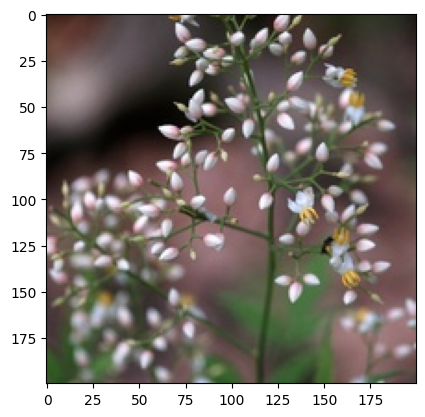

In [708]:
image = Image.open("./datasets/natural_images/flower/flower_0403.jpg")
print(f"Image size: {image.size}")
print(f"Image mode: {image.mode}")
plt.imshow(image)
plt.show()

Images are defined by pixels. Each pixel has a color defined by 3 values (Red, Green, Blue) ranging from 0 to 255 (0 black, 255 white). Black and white images have only one channel.

In [709]:
numpy_image = np.array(image)
print(f"Numpy array shape: {numpy_image.shape}")
print(f"Numpy array data type: {numpy_image.dtype}")
print(f"Total number of pixels: {numpy_image.size}")

Numpy array shape: (200, 200, 3)
Numpy array data type: uint8
Total number of pixels: 120000


### Upscaling images

We can load an image using the Pillow library and convert it to a numpy array for further processing.
We use torchvision transform to resize images.

Input data can be PIL or Tensor. If input is PIL Image, it is converted to Tensor first. Tensor format is C x H x W, in the range [0.0, 1.0] if the input is of type torch.FloatTensor, where C is the number of channels, H and W are height and width. For batch data, the shape will be B x C x H x W, where B is the batch size.

There are a lot of transformations available in torchvision.transforms: https://pytorch.org/vision/stable/transforms.html

In [710]:
def plot_images(original, transformed):
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(transformed)
    plt.title('Transformed Image')
    plt.axis('off')
    plt.show()

#### Change image size

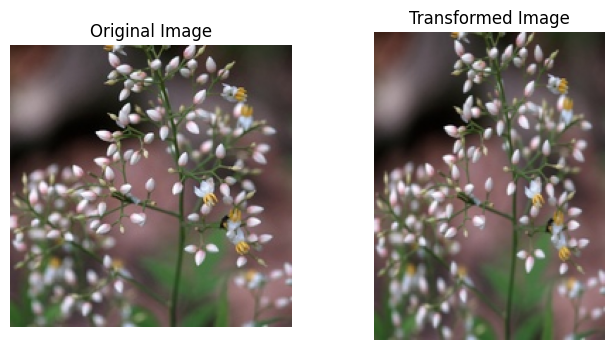

In [711]:
transforms = v2.Compose([
    v2.ToImage(), # Convert PIL Image to Tensor, it's done automatically if input is PIL Image
    v2.Resize((200, 150)),
    v2.ToPILImage(),
])

resized_image = transforms(image)
plot_images(image, resized_image)

#### Flip image

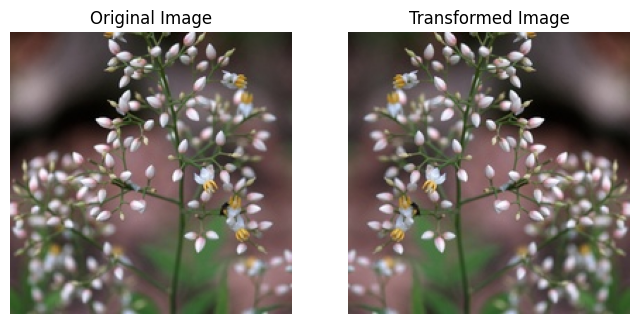

In [712]:
transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=1.0), # p=1.0 means always flip, p=0.5 means 50% chance
    v2.ToPILImage(),
])
flipped_image = transforms(image)
plot_images(image, flipped_image)

#### Color transformations

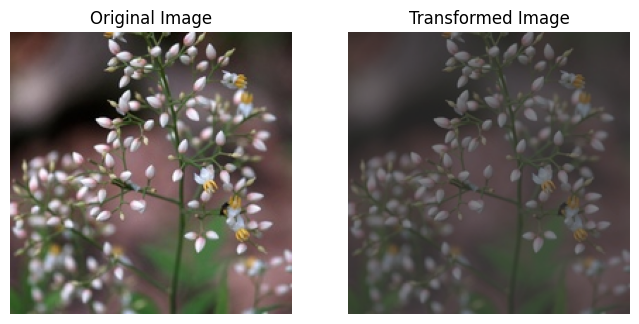

In [713]:
transforms = v2.Compose([
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1),
    v2.ToPILImage(),
])
color_jittered_image = transforms(image)
plot_images(image, color_jittered_image)

#### Crop image

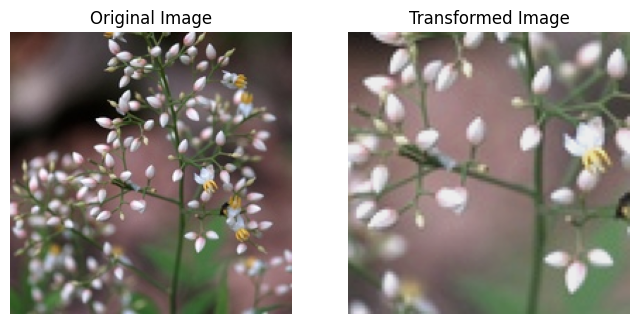

In [714]:
transforms = v2.Compose([
    v2.RandomCrop(size=(100, 100)), # Crop section is random
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    v2.ToPILImage(),
])
cropped_image = transforms(image)
plot_images(image, cropped_image)

#### Rotate image

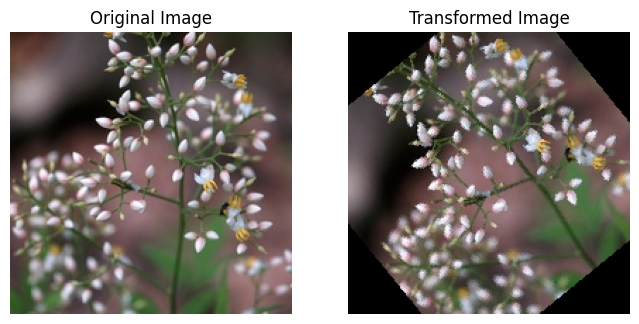

In [715]:
transforms = v2.Compose([
    v2.RandomRotation(degrees=45), # Rotate between -45 to +45 degrees
    v2.ToPILImage(),
])
rotated_image = transforms(image)
plot_images(image, rotated_image)

#### Normalize image

Neural networks work better with normalized data. For images, we can normalize each channel (R, G, B) to have mean 0 and standard deviation 1.

In [716]:
transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True), # Convert to float32 for normalization and scale to [0, 1]
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
normalized_image = transforms(image)

numpy_image = normalized_image.numpy()
print(f"Numpy array shape after normalization: {numpy_image.shape}")
print(f"Max pixel value after normalization: {numpy_image.max()}")
print(f"Min pixel value after normalization: {numpy_image.min()}")
print(f"Mean pixel value after normalization: {numpy_image.mean()}")

Numpy array shape after normalization: (3, 200, 200)
Max pixel value after normalization: 1.0
Min pixel value after normalization: -1.0
Mean pixel value after normalization: -0.24630944430828094


> 0.5 normalize the image between -1 and 1. For each channel: normalized_value = (value - mean) / std. But in other cases, we can use another mean and std values.

It would be possible to normalize it also between 0 and 1, dividing by 255. But in practice, normalizing between -1 and 1 works better for neural networks.

### Including transformations in the dataset class

We can include the transformations to the dataset in two ways:
1. Increase the dataset size with new duplicated and transformed images. For example, 25% new images with random transformations. This helps with small datasets.
2. Apply random transformations on the fly during training.

> Transformations are only applied to the training set, not to the validation or test sets. As we want to evaluate the model with real images, not transformed ones.

In [717]:
transforms_train = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224)), # Resize to 224x224 disregarding original aspect ratio
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.3),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

transforms_eval = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

## 3. DataLoader and Dataset

We can use Dataset but we will try ImageFolder, a generic data loader where the images are arranged in the way 'root/class_x/xxx.png'. First we will divide the dataset into training, validation and test sets. Then we will create DataLoaders for each set.

In [718]:
# Divide dataset into training, validation, and test sets
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder

full_dataset = torchvision.datasets.ImageFolder(root=dataset_dir)
dataset_size = len(full_dataset)
indices = list(range(dataset_size))
train_indices, temp_indices = train_test_split(indices, test_size=0.3, random_state=42)
val_indices, test_indices = train_test_split(temp_indices, test_size=0.5, random_state=42) 
train_dataset = ImageFolder(root=dataset_dir, transform=transforms_train)
val_dataset = ImageFolder(root=dataset_dir, transform=transforms_eval)
test_dataset = ImageFolder(root=dataset_dir, transform=transforms_eval)
train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)
test_dataset = Subset(test_dataset, test_indices)

print(f"Total dataset size: {dataset_size}")
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")


Total dataset size: 6899
Training set size: 4829
Validation set size: 1035
Test set size: 1035


> They CAN'T share the same ImageFolder instance, if not the transforms applied would be the last one defined.

In [719]:
sizes = set()
channels = set()

for i in range(len(train_dataset)):
    img, label = train_dataset[i]
    sizes.add(img.shape[1:])   # H, W
    channels.add(img.shape[0]) # C

print(f"Unique sizes: {sizes}")
print(f"Unique channels: {channels}")

Unique sizes: {torch.Size([224, 224])}
Unique channels: {3}


In [720]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [721]:
def imshow_tensor(image_tensor):
    image_tensor = image_tensor.clone().detach()
    image_tensor = image_tensor * 0.5 + 0.5  # Unnormalize
    np_image = image_tensor.numpy()
    plt.imshow(np.transpose(np_image, (1, 2, 0))) # Convert from (C, H, W) to (H, W, C) for plotting
    plt.axis('off')

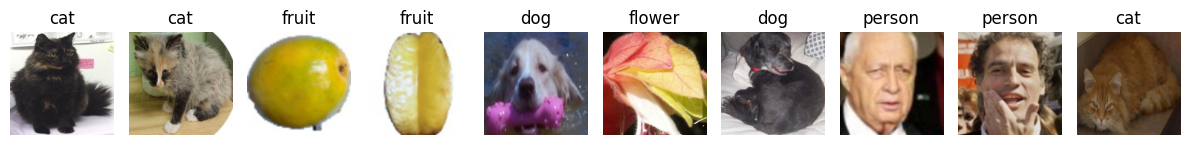

In [722]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
class_names = train_dataset.dataset.classes
show_images = 10

fig, axes = plt.subplots(1, show_images, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    with torch.no_grad():
        image, label = images[i], labels[i]
        plt.sca(ax)
        imshow_tensor(image)
        ax.set_title(class_names[label])
plt.tight_layout()
plt.show()

##  4. Define neural network

A conventional neural network (CNN) is a type of deep learning model that is particularly well-suited for image classification tasks. CNNs are designed to automatically and adaptively learn spatial hierarchies of features from input images.

It has different types of layers:
- Convolutional layers: These layers apply a set of learnable filters (also called kernels) to the input image. Each filter scans the image and produces a feature map that highlights specific patterns or features in the image, such as edges, textures, or shapes. The filters are learned during training through backpropagation.
- Pooling layers: These layers reduce the spatial dimensions of the feature maps produced by the convolutional layers. This helps to reduce the number of parameters and computations in the network, as well as to make the model more robust to small translations and distortions in the input image. Common pooling operations include max pooling and average pooling.
- Fully connected layers: These layers are similar to the ones used in traditional feedforward neural networks. They take the flattened output from the previous layers and connect every neuron to every neuron in the next layer. The final fully connected layer produces the output of the network, which is typically a probability distribution over the different classes in the classification task.

> Stride refers to the number of pixels by which the filter moves across the input image during the convolution operation. A stride of 1 means that the filter moves one pixel at a time, while a stride of 2 means that the filter moves two pixels at a time. Increasing the stride reduces the spatial dimensions of the output feature map, which can help to reduce the computational complexity of the network. However, it can also lead to a loss of information, as some pixels in the input image may be skipped during the convolution operation.

> Padding is the process of adding extra pixels around the border of the input image before applying the convolution operation. This is done to control the spatial dimensions of the output feature map. Without padding, the spatial dimensions of the output feature map will be smaller than those of the input image, as the filter cannot be applied to the border pixels. By adding padding, we can ensure that the filter can be applied to all pixels in the input image, which helps to preserve the spatial dimensions of the output feature map. Common types of padding include zero-padding (adding pixels with a value of 0) and reflection-padding (adding pixels that reflect the values of the border pixels).

### Convolutional layer (Conv2d)

Convolutional layer exit size = (W - F + 2P) / S + 1

Exit = H x W x D

Where:
- W: Input volume size (width/height)
- F: Receptive field size (filter/kernel size)
- P: Padding size
- S: Stride size
- D: Number of filters (out_channels)

In [723]:
image, label = images[0], labels[0]
num_filters = 18
print(f"Image tensor shape: {image.shape}")
print(f"Label: {label}, Class name: {class_names[label]}")
W = image.shape[1]  # assuming square images, height = width
F = 7
S = 1
P = 1
output_size = (W - F + 2 * P) // S + 1 # // to ensure integer division
print(f"Output size after convolution: {output_size} x {output_size} x {num_filters}")
simple_model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=num_filters, kernel_size=F, stride=S, padding=P),
)

Image tensor shape: torch.Size([3, 224, 224])
Label: 2, Class name: cat
Output size after convolution: 220 x 220 x 18


- in_channels: Number of channels in the input image (3 for RGB images)
- out_channels: Number of filters in the convolutional layer (number of output channels)
- kernel_size: Size of the filter (e.g., 3 for a 3x3 filter)
- stride: Number of pixels by which the filter moves across the input image
- padding: Number of pixels added to the border of the input image

### Pooling layer (MaxPool2d)

Pooling layer can be max pooling or average pooling. Max pooling takes the maximum value in each region, while average pooling takes the average value.

Pooling layer exit size = (W - F + 2P) / S + 1

Exit H x W x D

Where:
- W: Input volume size (width/height)
- F: Receptive field size (filter/kernel size)
- S: Stride size
- P: Padding size
- D: Number of filters (out_channels)

In [724]:
image, label = images[0], labels[0]
num_filters = 12
print(f"Image tensor shape: {image.shape}")
print(f"Label: {label}, Class name: {class_names[label]}")
W = image.shape[1]  # assuming square images, height = width
F = 2
S = 2
P = 0
output_size = (W - F + 2 * P) // S + 1 # // to ensure integer division
print(f"Output size after pooling: {output_size} x {output_size} x {num_filters}")
simple_model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=num_filters, kernel_size=3, stride=1, padding=1),
    nn.MaxPool2d(kernel_size=F, stride=S, padding=P)
)

Image tensor shape: torch.Size([3, 224, 224])
Label: 2, Class name: cat
Output size after pooling: 112 x 112 x 12


### Model definition with convolutional and pooling layers

We will define:
- A convolutional layer with 12 filters of size 3x3, stride 1 and padding 1.
- A max pooling layer with filter size 2x2 and stride 2.
- A Relu activation function
- A convolutional layer with 24 filters of size 3x3, stride 1 and padding 1.
- A max pooling layer with filter size 2x2 and stride 2.
- A Relu activation function
- A fully connected layer to output the class scores (8 classes).
- A log softmax activation function to get probabilities for each class.

> Log Softmax is numerically more stable than softmax, especially when dealing with very small probabilities. It helps to prevent numerical underflow issues that can occur when multiplying many small probabilities together.

In [725]:
class ImagePredictorCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImagePredictorCNN, self).__init__()
        self.features = nn.Sequential(
            # First convolutional layer
            nn.Conv2d(in_channels=3, out_channels=12, kernel_size=3, stride=1, padding=1),
            # Convolution output size = [(224 - 3 + 2*1) / 1 + 1] x [(224 - 3 + 2*1) / 1 + 1] x 12 = 224 x 224 x 12
            nn.MaxPool2d(kernel_size=2, stride=2),
            # output size = [(224 - 2 + 2*0) / 2 + 1] x [(224 - 2 + 2*0) / 2 + 1] x 12 = 112 x 112 x 12
            nn.ReLU(),
            # Second convolutional layer
            nn.Conv2d(in_channels=12, out_channels=24, kernel_size=3, stride=1, padding=1),
            # Convolution output size = [(112 - 3 + 2*1) / 1 + 1] x [(112 - 3 + 2*1) / 1 + 1] x 24 = 112 x 112 x 24
            nn.MaxPool2d(kernel_size=2, stride=2),
            # output size = [(112 - 2 + 2*0) / 2 + 1] x [(112 - 2 + 2*0) / 2 + 1] x 24 = 56 x 56 x 24
            nn.ReLU(),
            nn.Flatten(), # Flatten the output for the fully connected layer
            # Fully connected layer
            nn.Linear(in_features=56 * 56 * 24, out_features=num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        # return probabilities for each class with log-softmax
        return torch.log_softmax(x, dim=1)

In [726]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [727]:
model = ImagePredictorCNN(num_classes=len(class_names))
model = model.to(device)
print(model)

ImagePredictorCNN(
  (features): Sequential(
    (0): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=75264, out_features=8, bias=True)
  )
)


### Optimizer and loss function

In [728]:
loss_function = nn.CrossEntropyLoss() # Cross-entropy loss for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [729]:
def train(model, device, train_loader, loss_fn, optimizer):
    model.train()  # set model to training mode

    # Initalize variables for the metrics
    epoch_loss = 0
    elements = 0
    correct_train = 0

    for i_batch, (image, label) in enumerate(train_loader):
        image, label = image.to(device), label.to(device)

        optimizer.zero_grad()  # zero the gradients

        # reshape is done to match the output shape of the model
        # we could also use squeeze on the model output
        predictions = model(image)  # forward pass
        loss = loss_fn(predictions, label)  # compute loss

        loss.backward()  # backward pass
        optimizer.step()  # update weights

        # save metrics
        epoch_loss += loss.item()
        _, predicted = torch.max(predictions, 1) # takes the class with highest probability
        correct_train += (predicted == label).sum().item()
        elements += label.shape[0]

    # Calculate average loss and accuracy for the epoch
    loss_train = epoch_loss / i_batch
    accuracy_train = correct_train / elements

    return loss_train, accuracy_train

In [730]:
def evaluation(model, device, val_loader, loss_fn):
    model.eval()  # set model to evaluation mode

    # Initalize variables for the metrics
    epoch_loss = 0
    elements = 0
    correct_val = 0

    # we don't need gradients for validation, we just do forward pass
    with torch.no_grad():  # disable gradient computation
        for i_batch, (image, label) in enumerate(val_loader):
            image, label = image.to(device), label.to(device)

            predictions = model(image)  # forward pass

            loss = loss_fn(predictions, label)  # compute loss

            # save metrics
            epoch_loss += loss.item()
            _, predicted = torch.max(predictions, 1) # takes the class with highest probability
            correct_val += (predicted == label).sum().item()
            elements += label.shape[0] # length of the batch

    # Calculate average loss and accuracy for the epoch
    loss_val = epoch_loss / i_batch
    accuracy_val = correct_val / elements

    return loss_val, accuracy_val

In [731]:
def training_evaluation_loop(epochs, model, device, train_loader, val_loader, loss_fn, optimizer):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    total_time = 0

    for epoch in range(epochs):
        start_time = time.time()

        loss_train, accuracy_train = train(model, device, train_loader, loss_fn, optimizer)
        loss_val, accuracy_val = evaluation(model, device, val_loader, loss_fn)

        train_losses.append(loss_train)
        val_losses.append(loss_val)
        train_accuracies.append(accuracy_train)
        val_accuracies.append(accuracy_val)

        end_time = time.time()
        epoch_duration = end_time - start_time
        total_time += epoch_duration

        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {loss_train:.4f}, Train Acc: {accuracy_train:.4f} - "
              f"Val Loss: {loss_val:.4f}, Val Acc: {accuracy_val:.4f} - "
              f"Time: {epoch_duration:.2f}s")
        
    print(f"Total training time: {total_time:.2f}s")

    return train_losses, val_losses, train_accuracies, val_accuracies

## 5. Training the model

In [732]:
epochs = 10

train_losses, val_losses, train_accuracies, val_accuracies = training_evaluation_loop(
    epochs, model, device, train_loader, val_loader, loss_function, optimizer
)

Epoch 1/10 - Train Loss: 2.7116, Train Acc: 0.3154 - Val Loss: 1.4182, Val Acc: 0.5440 - Time: 51.46s
Epoch 2/10 - Train Loss: 1.2619, Train Acc: 0.5776 - Val Loss: 1.2654, Val Acc: 0.5903 - Time: 50.47s
Epoch 3/10 - Train Loss: 0.9731, Train Acc: 0.6784 - Val Loss: 1.0399, Val Acc: 0.6705 - Time: 49.31s
Epoch 4/10 - Train Loss: 0.7845, Train Acc: 0.7349 - Val Loss: 0.9650, Val Acc: 0.6966 - Time: 47.45s
Epoch 5/10 - Train Loss: 0.7315, Train Acc: 0.7486 - Val Loss: 1.0615, Val Acc: 0.6841 - Time: 46.61s
Epoch 6/10 - Train Loss: 0.6230, Train Acc: 0.7879 - Val Loss: 0.9144, Val Acc: 0.7169 - Time: 47.87s
Epoch 7/10 - Train Loss: 0.6206, Train Acc: 0.7898 - Val Loss: 1.0978, Val Acc: 0.7014 - Time: 50.87s
Epoch 8/10 - Train Loss: 0.5846, Train Acc: 0.8024 - Val Loss: 1.0645, Val Acc: 0.6860 - Time: 50.87s
Epoch 9/10 - Train Loss: 0.5556, Train Acc: 0.8124 - Val Loss: 1.0141, Val Acc: 0.7121 - Time: 50.87s
Epoch 10/10 - Train Loss: 0.5389, Train Acc: 0.8192 - Val Loss: 1.0076, Val Acc: 0

## 6. Evaluating the model

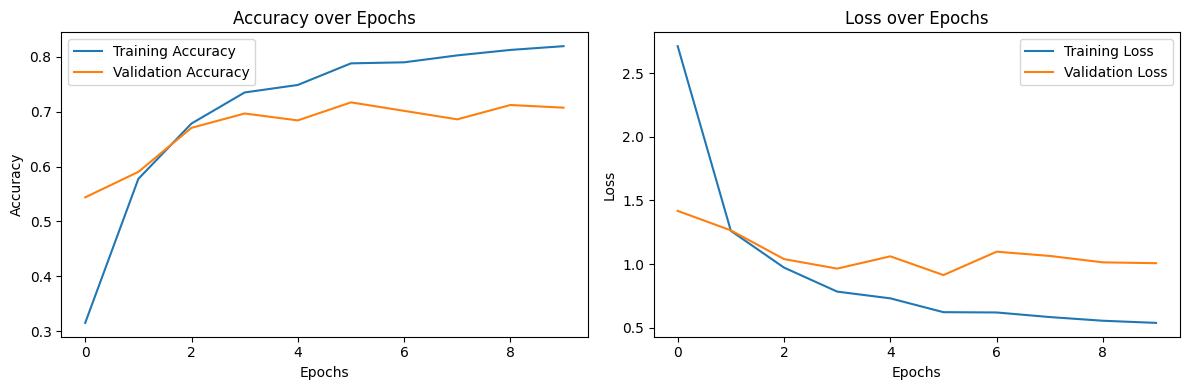

In [733]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(range(epochs), train_accuracies, label='Training Accuracy')
axes[0].plot(range(epochs), val_accuracies, label='Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].legend()

# Loss
axes[1].plot(range(epochs), train_losses, label='Training Loss')
axes[1].plot(range(epochs), val_losses, label='Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()


### Testing the model

In [747]:
def predictions(model, test_loader, device):
    # predicted values and reals
    predictions = []
    true_labels = []

    correct = 0

    model.eval()  # set model to evaluation mode
    with torch.no_grad():  # disable gradient computation
        for image, label in test_loader:
            image, label = image.to(device), label.to(device)

            # calculate exit of the model
            outputs = model(image)  # forward pass

            _, predicted = torch.max(outputs.data, 1) # takes the class with highest probability

            # compute number of correct predictions
            correct += torch.sum(predicted == label).item()
            predictions.append(predicted.detach().cpu().numpy())
            true_labels.append(label.detach().cpu().numpy())

        predictions = np.hstack(predictions)
        true_labels = np.hstack(true_labels)
        print(f'Test set accuracy: {correct / (len(true_labels))*100:.2f}%')

    return predictions, true_labels

In [748]:
predicted, true_labels = predictions(model, test_loader, device)

Test set accuracy: 72.66%


Accuracy on test set: 72.66% let's see the confusion matrix so we can analyze the errors made by the model per class.

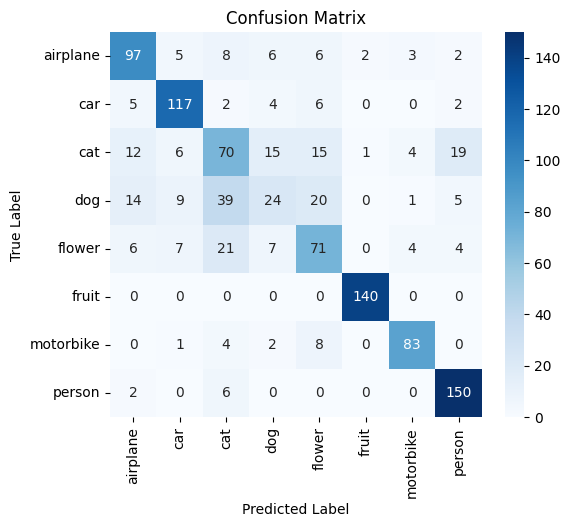

In [749]:
cm = confusion_matrix(true_labels, predicted)
tick_marks = np.arange(len(class_names))

df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='g', cmap='Blues', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Model has the highest confusion between classes 'cat' and 'dog', which is expected as they are similar animals.

> Low precission and errors in other classes could be due to the resized images losing important features for classification.